# Visual Genome EDA

Notebook này kiểm tra processed Task 1 và Task 2, rà soát chất lượng dữ liệu, xem phân phối nhãn, và hiển thị một vài mẫu trước khi train.

## Notebook Outline

1. Setup & Load Data
2. Inspect Dataset Structure
3. Check Missing Values and Duplicates
4. Analyze Target/Class Distribution
5. Analyze Label Distribution Across Object / Attribute / Relation Files
6. Univariate Analysis
7. Bivariate Analysis
8. Feature Correlation Analysis
9. Visualize Key Patterns

## 1. Setup & Load Data

Load processed annotations, vocabularies, and basic path helpers before running the rest of the EDA.

In [ ]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from PIL import Image, ImageDraw

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_colwidth', 120)

BASE_DIR = Path.cwd()
if not (BASE_DIR / 'data').exists() and (BASE_DIR.parent / 'data').exists():
    BASE_DIR = BASE_DIR.parent

RAW_DIR = BASE_DIR / 'data' / 'raw'
PROCESSED_DIR = BASE_DIR / 'data' / 'processed'


def load_json(path):
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)


def load_split_df(task, split):
    path = PROCESSED_DIR / task / split / 'annotations.json'
    payload = load_json(path)
    samples = payload.get('samples', payload)
    return pd.DataFrame(samples)


def invert_vocab(path):
    vocab = load_json(path)
    return {int(idx): label for label, idx in vocab.items()}


def expand_bbox(df, column, prefix):
    if df.empty:
        return df.copy()
    values = df[column].apply(
        lambda value: value if isinstance(value, list) and len(value) == 4 else [np.nan, np.nan, np.nan, np.nan]
    )
    result = df.copy()
    result[[f'{prefix}_x', f'{prefix}_y', f'{prefix}_w', f'{prefix}_h']] = pd.DataFrame(values.tolist(), index=result.index)
    result[f'{prefix}_area'] = result[f'{prefix}_w'] * result[f'{prefix}_h']
    result[f'{prefix}_aspect_ratio'] = result[f'{prefix}_w'] / result[f'{prefix}_h'].replace(0, np.nan)
    return result


def safe_len(value):
    return len(value) if isinstance(value, list) else 0


def sample_image_path(image_id):
    return RAW_DIR / 'images' / f'{int(image_id)}.jpg'


def load_image(image_id):
    path = sample_image_path(image_id)
    if not path.exists():
        return None
    return Image.open(path).convert('RGB')


task1_object_vocab = invert_vocab(PROCESSED_DIR / 'task1' / 'object_vocab.json')
task1_attribute_vocab = invert_vocab(PROCESSED_DIR / 'task1' / 'attribute_vocab.json')
task2_relation_vocab = invert_vocab(PROCESSED_DIR / 'task2' / 'relation_vocab.json')

task1_splits = {}
for split in ['train', 'val', 'test']:
    df = load_split_df('task1', split)
    if not df.empty:
        df = expand_bbox(df, 'bbox', 'bbox')
        df['attribute_count'] = df['attribute_labels'].apply(safe_len)
        df['object_name'] = df['object_label'].map(task1_object_vocab).fillna('<UNK>')
        df['attribute_names'] = df['attribute_labels'].apply(
            lambda ids: [task1_attribute_vocab.get(int(idx), '<UNK>') for idx in ids]
        )
    task1_splits[split] = df


task2_splits = {}
for split in ['train', 'val', 'test']:
    df = load_split_df('task2', split)
    if not df.empty:
        df = expand_bbox(df, 'subject_bbox', 'subject_bbox')
        df = expand_bbox(df, 'object_bbox', 'object_bbox')
        df['pair_area_sum'] = df['subject_bbox_area'] + df['object_bbox_area']
        df['pair_area_ratio'] = df['subject_bbox_area'] / df['object_bbox_area'].replace(0, np.nan)
        df['relation_name'] = df['relation_label'].map(task2_relation_vocab).fillna('<UNK>')
    task2_splits[split] = df


task1_train = task1_splits['train']
task2_train = task2_splits['train']

split_summary = pd.DataFrame(
    [
        {
            'task': 'task1',
            'split': split,
            'samples': len(df),
            'images': df['image_id'].nunique() if not df.empty else 0,
        }
        for split, df in task1_splits.items()
    ]
    + [
        {
            'task': 'task2',
            'split': split,
            'samples': len(df),
            'images': df['image_id'].nunique() if not df.empty else 0,
        }
        for split, df in task2_splits.items()
    ]
)

display(split_summary)

,task,split,samples,images
0,task1,train,1782647,77093
1,task1,val,381996,15049
2,task1,test,381996,13823
3,task2,train,1437931,71440
4,task2,val,308128,17460
5,task2,test,308129,15575


## 2. Inspect Dataset Structure

Task 1 train shape: (1782647, 14)
Task 2 train shape: (1437931, 23)


,dataset,rows,columns
0,task1_train,1782647,14
1,task2_train,1437931,23


,image_id,object_id,bbox,object_label,attribute_labels,bbox_x,bbox_y,bbox_w,bbox_h,bbox_area,bbox_aspect_ratio,attribute_count,object_name,attribute_names
0,1,1058498,"[421, 91, 79, 339]",46,"[4, 16]",421,91,79,339,26781,0.233038,2,clock,"[green, tall]"
1,1,5046,"[77, 328, 714, 262]",36,[],77,328,714,262,187068,2.725191,0,street,[]
2,1,1058529,"[238, 249, 60, 262]",1,[],238,249,60,262,15720,0.229008,0,man,[]


,column,dtype
0,image_id,int64
1,object_id,int64
2,bbox,object
3,object_label,int64
4,attribute_labels,object
5,bbox_x,int64
6,bbox_y,int64
7,bbox_w,int64
8,bbox_h,int64
9,bbox_area,int64


,image_id,relationship_id,subject_bbox,object_bbox,subject_name,object_name,relation_label,image_info,subject_bbox_x,subject_bbox_y,subject_bbox_w,subject_bbox_h,subject_bbox_area,subject_bbox_aspect_ratio,object_bbox_x,object_bbox_y,object_bbox_w,object_bbox_h,object_bbox_area,object_bbox_aspect_ratio,pair_area_sum,pair_area_ratio,relation_name
0,1,15927,"[119, 338, 274, 192]","[77, 328, 714, 262]",shade,street,1,"{'width': 800, 'height': 600}",119,338,274,192,52608,1.427083,77,328,714,262,187068,2.725191,239676,0.281224,on
1,1,15928,"[238, 249, 60, 262]","[243, 489, 52, 26]",man,sneakers,17,"{'width': 800, 'height': 600}",238,249,60,262,15720,0.229008,243,489,52,26,1352,2.000000,17072,11.627219,wears
2,1,15929,"[479, 315, 74, 98]","[514, 366, 23, 15]",car,headlight,2,"{'width': 800, 'height': 600}",479,315,74,98,7252,0.755102,514,366,23,15,345,1.533333,7597,21.020290,has


...

Top Task 1 object classes


,count
object_name,
man,64162
window,49536
person,45100
building,35280
tree,35271
shirt,33030
wall,32518
ground,30061
woman,28702


Top Task 2 relation classes


,count
relation_name,
on,446650
has,183553
in,154560
wearing,88362
of,87688
with,44166
behind,29424
holding,26635
on top of,25330


C:\Users\caoha\AppData\Local\Temp\ipykernel_234652\792363308.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_objects.values, y=top_objects.index, ax=axes[0], palette='Blues_r')
C:\Users\caoha\AppData\Local\Temp\ipykernel_234652\792363308.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_relations.values, y=top_relations.index, ax=axes[1], palette='Greens_r')


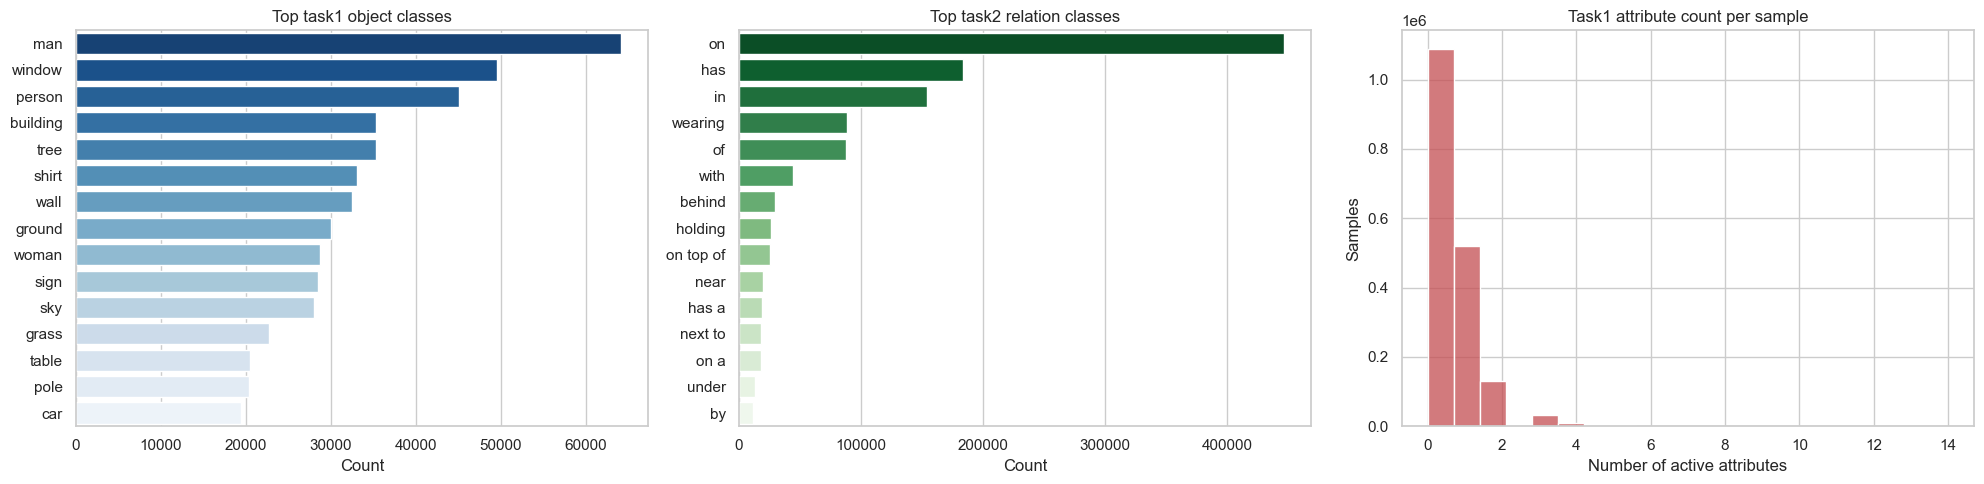

,count,mean,std,min,25%,50%,75%,max
bbox_w,1782647.0,139.262059,149.043845,1.000000,37.0,81.000000,182.000000,1280.0
bbox_h,1782647.0,109.672039,103.837276,1.000000,35.0,74.000000,150.000000,1272.0
bbox_area,1782647.0,24051.336204,46602.128823,1.000000,1500.0,6200.000000,25080.000000,1389960.0
bbox_aspect_ratio,1782647.0,1.655060,2.638553,0.002294,0.7,1.106952,1.808219,592.0
attribute_count,1782647.0,0.524102,0.790176,0.000000,0.0,0.000000,1.000000,14.0


,count,mean,std,min,25%,50%,75%,max
subject_bbox_w,1437931.0,136.437897,133.482214,1.000000,40.000000,88.000000,186.000000,1280.0
subject_bbox_h,1437931.0,123.870219,112.950902,1.000000,39.000000,84.000000,178.000000,1270.0
subject_bbox_area,1437931.0,25603.000824,43614.674711,1.000000,1755.000000,7566.000000,30336.000000,1158400.0
object_bbox_w,1437931.0,213.497017,185.762565,1.000000,59.000000,150.000000,344.000000,1278.0
object_bbox_h,1437931.0,151.038971,125.896809,1.000000,50.000000,116.000000,222.000000,1270.0
object_bbox_area,1437931.0,46334.475186,68811.800864,1.000000,3344.000000,18258.000000,65698.000000,1389960.0
pair_area_sum,1437931.0,71937.476010,85309.484702,4.000000,15048.000000,45202.000000,100734.000000,2001646.0
pair_area_ratio,1437931.0,17.313383,549.807657,0.000006,0.075334,0.460974,3.279762,182655.0


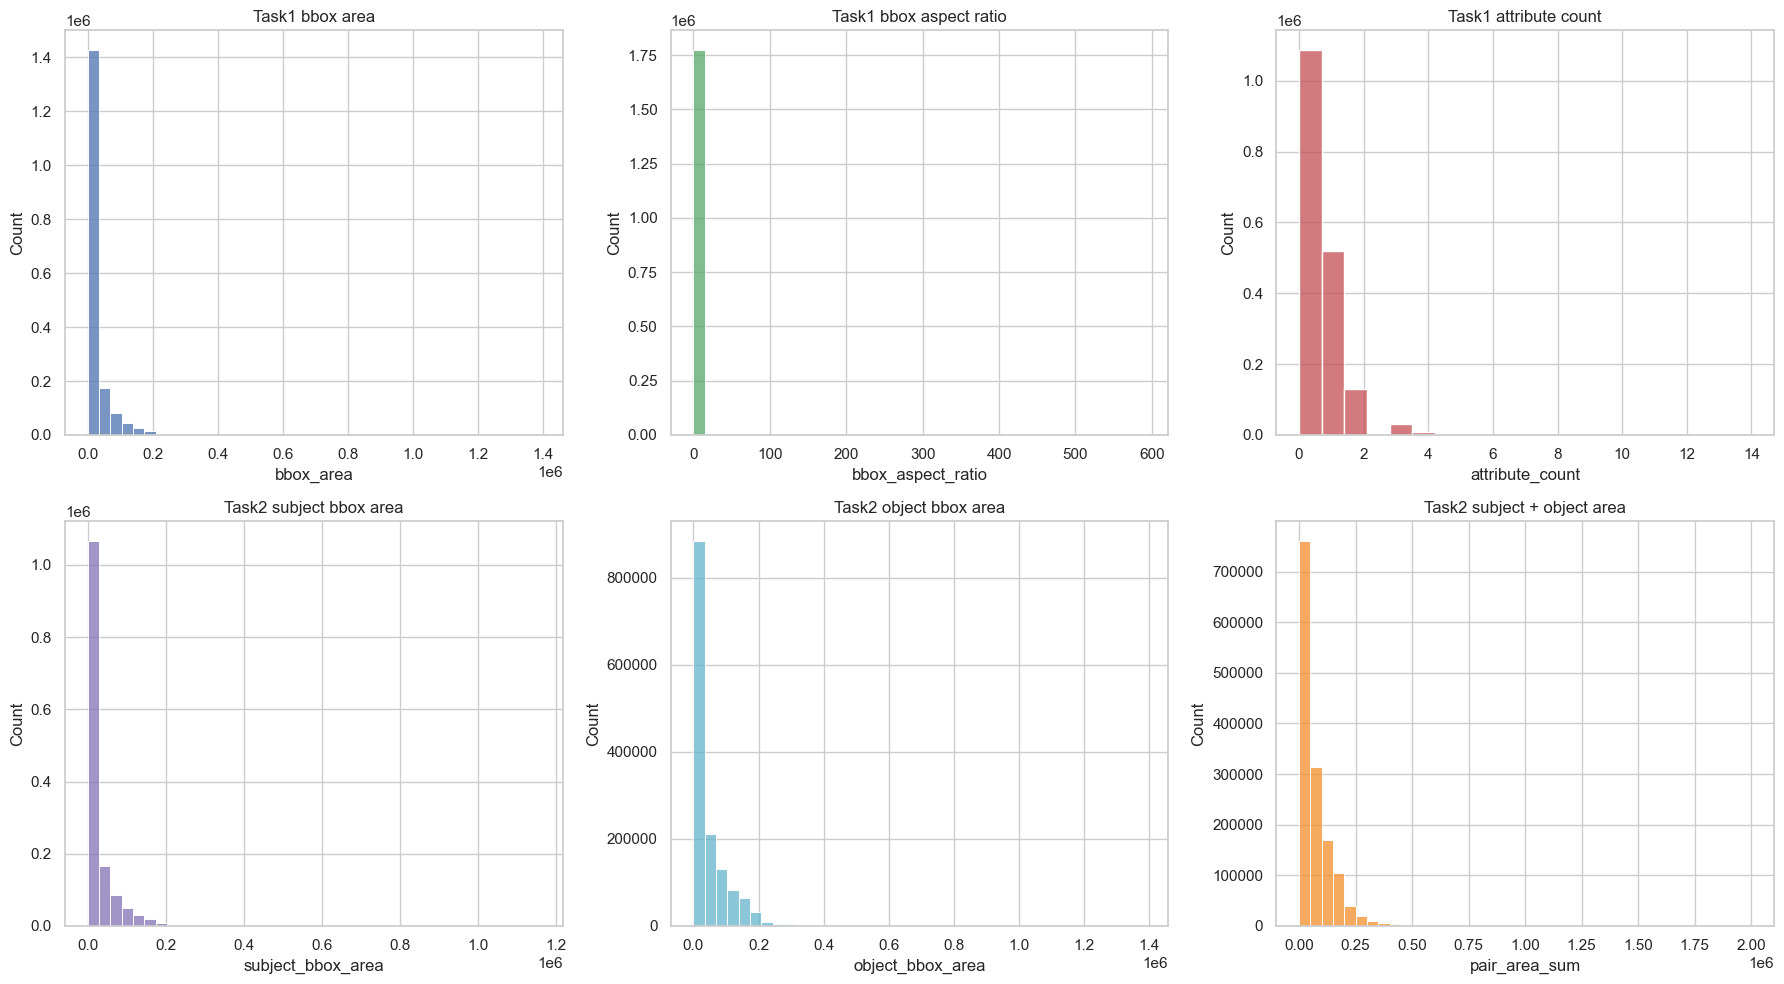

,object_name,sample_count,mean_bbox_area,mean_attribute_count
0,man,64162,30374.809358,0.219133
1,window,49536,9025.849201,0.230115
2,person,45100,17065.059534,0.162195
3,building,35280,64290.204195,0.481604
4,tree,35271,24126.966998,0.555726
5,shirt,33030,14697.301211,0.943082
6,wall,32518,51666.732610,0.468664
7,ground,30061,39180.805329,0.178038
8,woman,28702,32932.279214,0.235872
9,sign,28451,10725.437454,0.813750


,relation_name,sample_count,mean_subject_area,mean_object_area,mean_pair_area_sum
0,on,446650,13538.025570,61410.432036,74948.457607
1,has,183553,55364.640349,8663.184405,64027.824754
2,in,154560,19536.509796,73475.584834,93012.094630
3,wearing,88362,39597.307078,9296.342319,48893.649397
4,of,87688,11350.510127,50542.968000,61893.478127
5,with,44166,37137.060907,12044.398134,49181.459041
6,behind,29424,32084.896785,54308.377991,86393.274776
7,holding,26635,42263.926375,14556.860710,56820.787085
8,on top of,25330,16598.883340,65520.681129,82119.564469
9,near,20163,23308.663145,45383.572683,68692.235828


C:\Users\caoha\AppData\Local\Temp\ipykernel_234652\792363308.py:143: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=task1_bivariate, y='object_name', x='mean_bbox_area', ax=axes[0], palette='Blues_r')
C:\Users\caoha\AppData\Local\Temp\ipykernel_234652\792363308.py:148: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=task2_bivariate, y='relation_name', x='mean_pair_area_sum', ax=axes[1], palette='Purples_r')


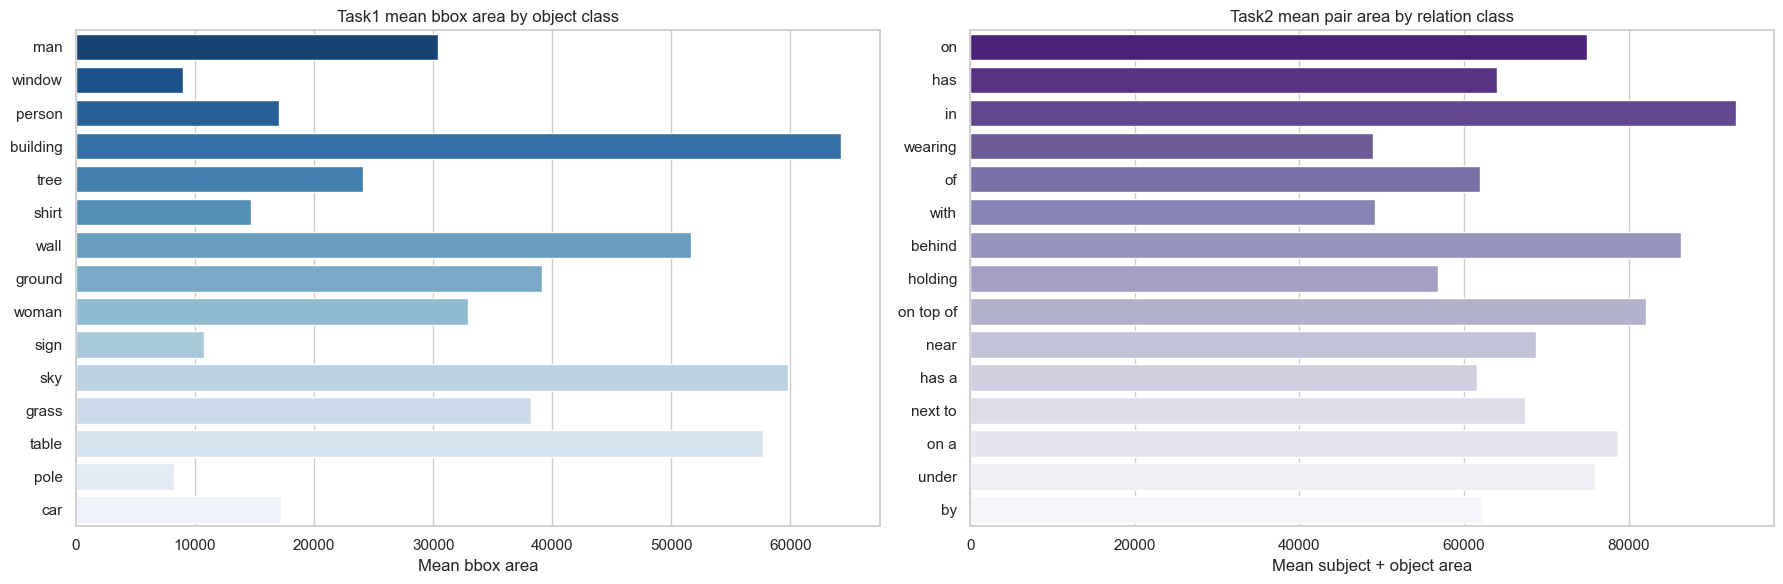

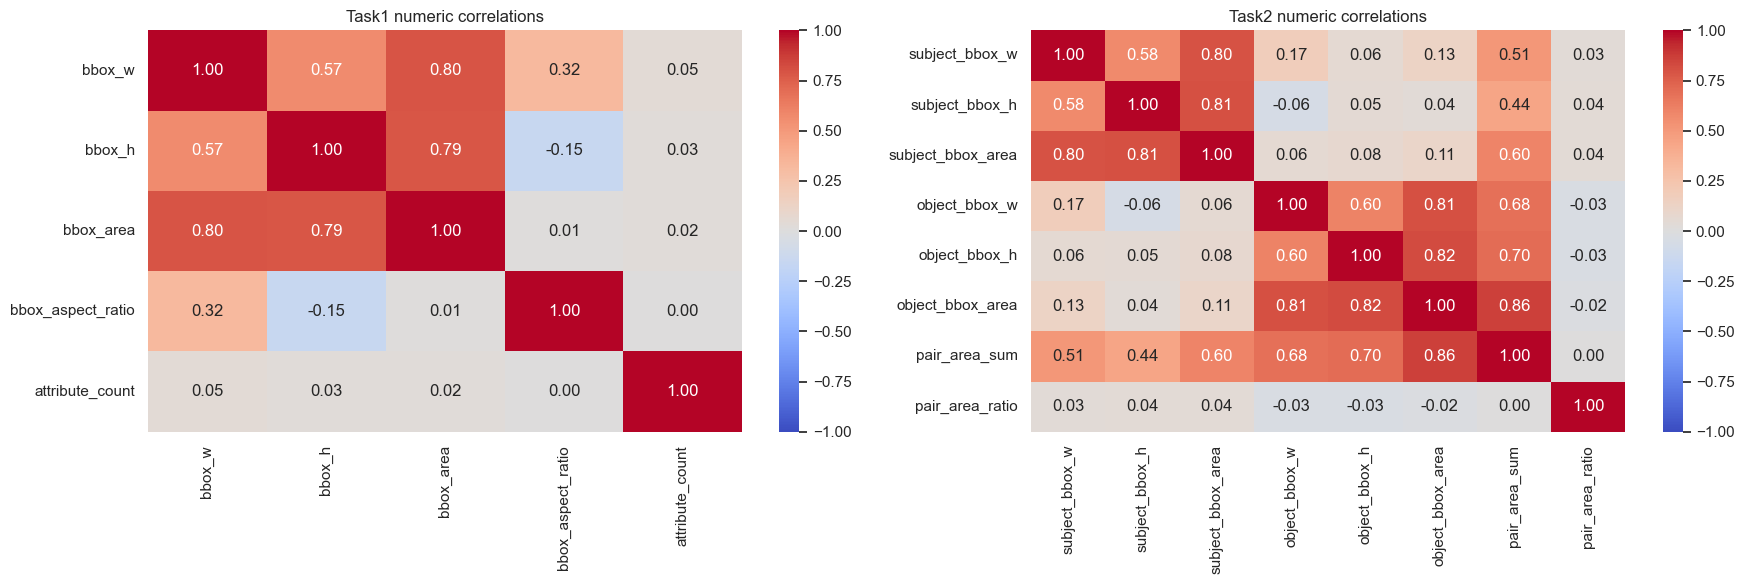

In [3]:
print('Task 1 train shape:', task1_train.shape)
print('Task 2 train shape:', task2_train.shape)

display(
    pd.DataFrame(
        [
            {'dataset': 'task1_train', 'rows': len(task1_train), 'columns': len(task1_train.columns)},
            {'dataset': 'task2_train', 'rows': len(task2_train), 'columns': len(task2_train.columns)},
        ]
    )
)

display(task1_train.head(3))
display(task1_train.dtypes.to_frame('dtype').reset_index().rename(columns={'index': 'column'}))
display(task2_train.head(3))
display(task2_train.dtypes.to_frame('dtype').reset_index().rename(columns={'index': 'column'}))

# 3. Check Missing Values and Duplicates
quality_rows = []
for dataset_name, df, key_cols in [
    ('task1_train', task1_train, ['image_id', 'object_id']),
    ('task2_train', task2_train, ['image_id', 'relationship_id']),
]:
    key_frame = df[key_cols]
    quality_rows.append(
        {
            'dataset': dataset_name,
            'rows': len(df),
            'missing_cells': int(df.isna().sum().sum()),
            'duplicate_rows': int(key_frame.duplicated().sum()),
            'duplicate_key_rows': int(key_frame.duplicated(keep=False).sum()),
        }
    )

quality_df = pd.DataFrame(quality_rows)
display(quality_df)

for dataset_name, df in [('task1_train', task1_train), ('task2_train', task2_train)]:
    missing = df.isna().sum()
    missing = missing[missing > 0].sort_values(ascending=False)
    if not missing.empty:
        print(f'Missing values for {dataset_name}:')
        display(missing.to_frame('missing_values'))

# 4. Analyze Target/Class Distribution
top_objects = task1_train['object_name'].value_counts().head(15)
top_relations = task2_train['relation_name'].value_counts().head(15)

print('Top Task 1 object classes')
display(top_objects.to_frame('count'))
print('Top Task 2 relation classes')
display(top_relations.to_frame('count'))

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
sns.barplot(x=top_objects.values, y=top_objects.index, ax=axes[0], palette='Blues_r')
axes[0].set_title('Top task1 object classes')
axes[0].set_xlabel('Count')
axes[0].set_ylabel('')

sns.barplot(x=top_relations.values, y=top_relations.index, ax=axes[1], palette='Greens_r')
axes[1].set_title('Top task2 relation classes')
axes[1].set_xlabel('Count')
axes[1].set_ylabel('')

sns.histplot(task1_train['attribute_count'], bins=20, ax=axes[2], color='#C44E52')
axes[2].set_title('Task1 attribute count per sample')
axes[2].set_xlabel('Number of active attributes')
axes[2].set_ylabel('Samples')

plt.tight_layout()
plt.show()

# 5. Univariate Analysis
numeric_summary_task1 = task1_train[['bbox_w', 'bbox_h', 'bbox_area', 'bbox_aspect_ratio', 'attribute_count']].describe().T
numeric_summary_task2 = task2_train[
    [
        'subject_bbox_w',
        'subject_bbox_h',
        'subject_bbox_area',
        'object_bbox_w',
        'object_bbox_h',
        'object_bbox_area',
        'pair_area_sum',
        'pair_area_ratio',
    ]
].describe().T

display(numeric_summary_task1)
display(numeric_summary_task2)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
sns.histplot(task1_train['bbox_area'], bins=40, ax=axes[0, 0], color='#4C72B0')
axes[0, 0].set_title('Task1 bbox area')

sns.histplot(task1_train['bbox_aspect_ratio'].replace([np.inf, -np.inf], np.nan).dropna(), bins=40, ax=axes[0, 1], color='#55A868')
axes[0, 1].set_title('Task1 bbox aspect ratio')

sns.histplot(task1_train['attribute_count'], bins=20, ax=axes[0, 2], color='#C44E52')
axes[0, 2].set_title('Task1 attribute count')

sns.histplot(task2_train['subject_bbox_area'], bins=40, ax=axes[1, 0], color='#8172B3')
axes[1, 0].set_title('Task2 subject bbox area')

sns.histplot(task2_train['object_bbox_area'], bins=40, ax=axes[1, 1], color='#64B5CD')
axes[1, 1].set_title('Task2 object bbox area')

sns.histplot(task2_train['pair_area_sum'], bins=40, ax=axes[1, 2], color='#F28E2B')
axes[1, 2].set_title('Task2 subject + object area')

plt.tight_layout()
plt.show()

# 6. Bivariate Analysis
task1_bivariate = (
    task1_train.groupby('object_name')
    .agg(
        sample_count=('object_name', 'size'),
        mean_bbox_area=('bbox_area', 'mean'),
        mean_attribute_count=('attribute_count', 'mean'),
    )
    .sort_values('sample_count', ascending=False)
    .head(15)
    .reset_index()
)

task2_bivariate = (
    task2_train.groupby('relation_name')
    .agg(
        sample_count=('relation_name', 'size'),
        mean_subject_area=('subject_bbox_area', 'mean'),
        mean_object_area=('object_bbox_area', 'mean'),
        mean_pair_area_sum=('pair_area_sum', 'mean'),
    )
    .sort_values('sample_count', ascending=False)
    .head(15)
    .reset_index()
)

display(task1_bivariate)
display(task2_bivariate)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.barplot(data=task1_bivariate, y='object_name', x='mean_bbox_area', ax=axes[0], palette='Blues_r')
axes[0].set_title('Task1 mean bbox area by object class')
axes[0].set_xlabel('Mean bbox area')
axes[0].set_ylabel('')

sns.barplot(data=task2_bivariate, y='relation_name', x='mean_pair_area_sum', ax=axes[1], palette='Purples_r')
axes[1].set_title('Task2 mean pair area by relation class')
axes[1].set_xlabel('Mean subject + object area')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

# 7. Feature Correlation Analysis
task1_corr_cols = ['bbox_w', 'bbox_h', 'bbox_area', 'bbox_aspect_ratio', 'attribute_count']
task2_corr_cols = [
    'subject_bbox_w',
    'subject_bbox_h',
    'subject_bbox_area',
    'object_bbox_w',
    'object_bbox_h',
    'object_bbox_area',
    'pair_area_sum',
    'pair_area_ratio',
]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.heatmap(
    task1_train[task1_corr_cols].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    ax=axes[0],
)
axes[0].set_title('Task1 numeric correlations')

sns.heatmap(
    task2_train[task2_corr_cols].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    ax=axes[1],
)
axes[1].set_title('Task2 numeric correlations')

plt.tight_layout()
plt.show()

## 5. Analyze Label Distribution Across Object / Attribute / Relation Files

Aggregate counts across all processed splits so the notebook shows how object, attribute, and relation labels are distributed in the full dataset, not just the train split.

,label_type,unique_labels,total_occurrences,max_count,median_count,mean_count,top1_share,top10_share,top20_share
0,object,300,2546639,93962,4997.5,8488.796667,0.036896,0.212152,0.323164
1,attribute,200,1260725,203275,1296.0,6303.625000,0.161237,0.588182,0.716775
2,relation,100,2054188,667990,3379.0,20541.880000,0.325184,0.775771,0.863839


,object_name,count
0,man,93962
1,person,69318
2,window,69105
3,tree,49290
4,building,46847
5,shirt,45755
6,wall,44663
7,woman,41364
8,sign,40186
9,sky,39784


,attribute_name,count
0,white,203275
1,black,125660
2,blue,82085
3,green,81341
4,brown,65226
5,red,65067
6,yellow,38939
7,large,29578
8,small,28222
9,gray,22143


,relation_name,count
0,on,667990
1,has,245977
2,in,225353
3,of,129214
4,wearing,124834
5,with,63608
6,behind,39961
7,holding,37483
8,on top of,31564
9,on a,27596


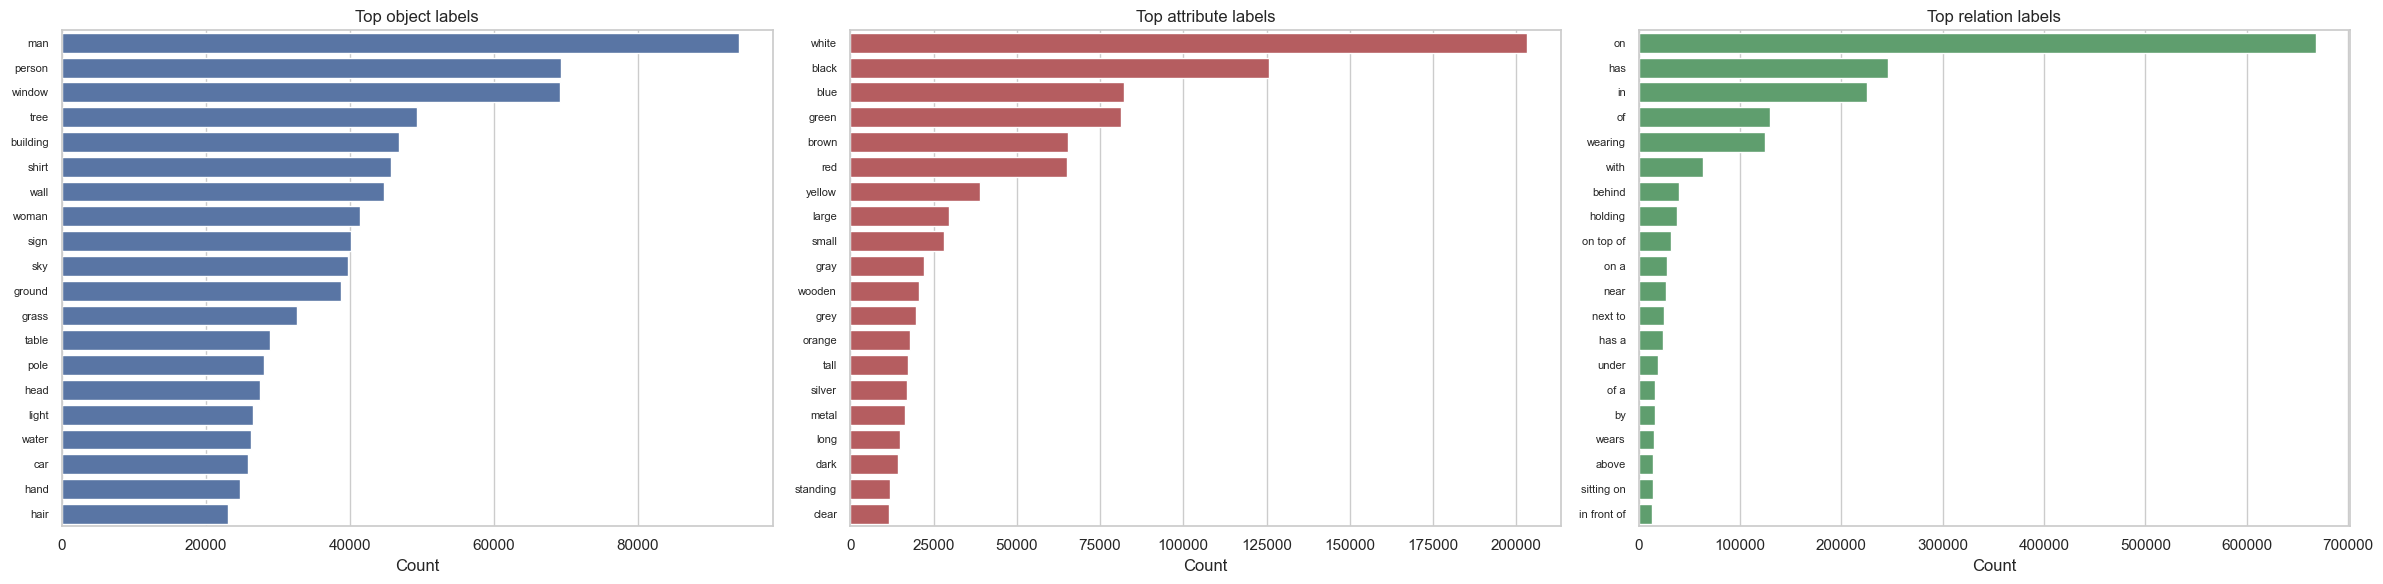

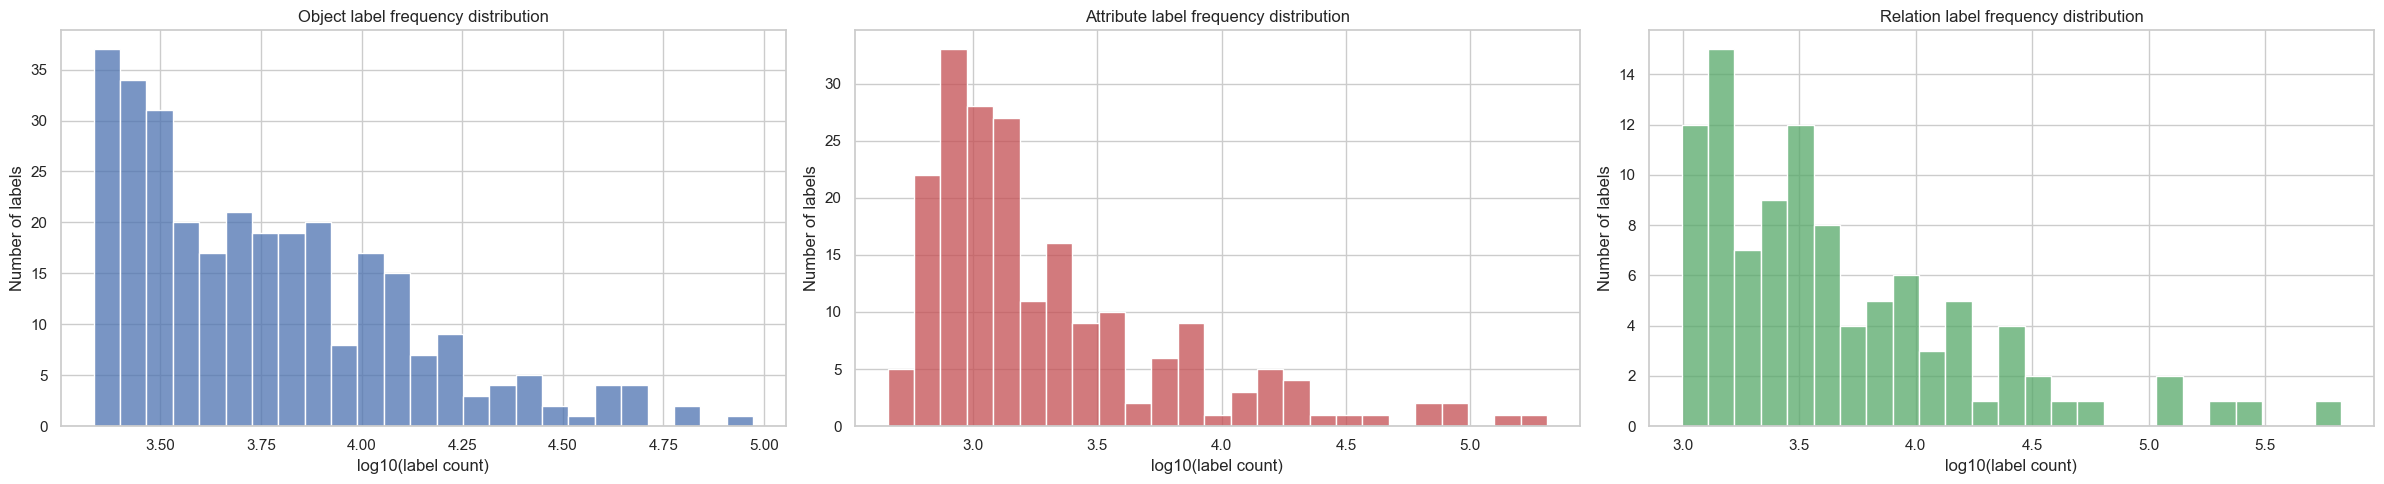

In [7]:
task1_object_label_series = [df['object_name'] for df in task1_splits.values() if not df.empty]
task1_attribute_label_series = [df['attribute_names'].explode() for df in task1_splits.values() if not df.empty]
task2_relation_label_series = [df['relation_name'] for df in task2_splits.values() if not df.empty]

if task1_object_label_series:
    task1_object_counts_all = pd.concat(task1_object_label_series, ignore_index=True).value_counts()
else:
    task1_object_counts_all = pd.Series(dtype=int)

if task1_attribute_label_series:
    task1_attribute_counts_all = pd.concat(task1_attribute_label_series, ignore_index=True).dropna().value_counts()
else:
    task1_attribute_counts_all = pd.Series(dtype=int)

if task2_relation_label_series:
    task2_relation_counts_all = pd.concat(task2_relation_label_series, ignore_index=True).value_counts()
else:
    task2_relation_counts_all = pd.Series(dtype=int)


task1_object_counts_all_df = task1_object_counts_all.rename_axis('object_name').reset_index(name='count')
task1_attribute_counts_all_df = task1_attribute_counts_all.rename_axis('attribute_name').reset_index(name='count')
task2_relation_counts_all_df = task2_relation_counts_all.rename_axis('relation_name').reset_index(name='count')


def summarize_label_distribution(label_type, counts):
    values = counts.to_numpy()
    total_occurrences = int(values.sum()) if len(values) else 0
    return {
        'label_type': label_type,
        'unique_labels': int(len(counts)),
        'total_occurrences': total_occurrences,
        'max_count': int(values.max()) if len(values) else 0,
        'median_count': float(np.median(values)) if len(values) else 0.0,
        'mean_count': float(values.mean()) if len(values) else 0.0,
        'top1_share': float(values[0] / total_occurrences) if total_occurrences else 0.0,
        'top10_share': float(values[:10].sum() / total_occurrences) if total_occurrences else 0.0,
        'top20_share': float(values[:20].sum() / total_occurrences) if total_occurrences else 0.0,
    }


label_distribution_summary = pd.DataFrame(
    [
        summarize_label_distribution('object', task1_object_counts_all),
        summarize_label_distribution('attribute', task1_attribute_counts_all),
        summarize_label_distribution('relation', task2_relation_counts_all),
    ]
)

display(label_distribution_summary)
display(task1_object_counts_all_df.head(20))
display(task1_attribute_counts_all_df.head(20))
display(task2_relation_counts_all_df.head(20))


def plot_top_labels(ax, counts, title, color):
    top_counts = counts.head(20)
    sns.barplot(x=top_counts.values, y=top_counts.index, ax=ax, color=color)
    ax.set_title(title)
    ax.set_xlabel('Count')
    ax.set_ylabel('')
    ax.tick_params(axis='y', labelsize=8)


fig, axes = plt.subplots(1, 3, figsize=(24, 6))
plot_top_labels(axes[0], task1_object_counts_all, 'Top object labels', '#4C72B0')
plot_top_labels(axes[1], task1_attribute_counts_all, 'Top attribute labels', '#C44E52')
plot_top_labels(axes[2], task2_relation_counts_all, 'Top relation labels', '#55A868')
plt.tight_layout()
plt.show()


def plot_log_frequency(ax, counts, title, color):
    values = counts.to_numpy()
    values = values[values > 0]
    if len(values) == 0:
        ax.axis('off')
        return
    sns.histplot(np.log10(values), bins=25, ax=ax, color=color)
    ax.set_title(title)
    ax.set_xlabel('log10(label count)')
    ax.set_ylabel('Number of labels')


fig, axes = plt.subplots(1, 3, figsize=(24, 5))
plot_log_frequency(axes[0], task1_object_counts_all, 'Object label frequency distribution', '#4C72B0')
plot_log_frequency(axes[1], task1_attribute_counts_all, 'Attribute label frequency distribution', '#C44E52')
plot_log_frequency(axes[2], task2_relation_counts_all, 'Relation label frequency distribution', '#55A868')
plt.tight_layout()
plt.show()

## 8. Visualize Key Patterns

Draw a few example images with bounding boxes and relation pairs so the raw annotations are easy to inspect.

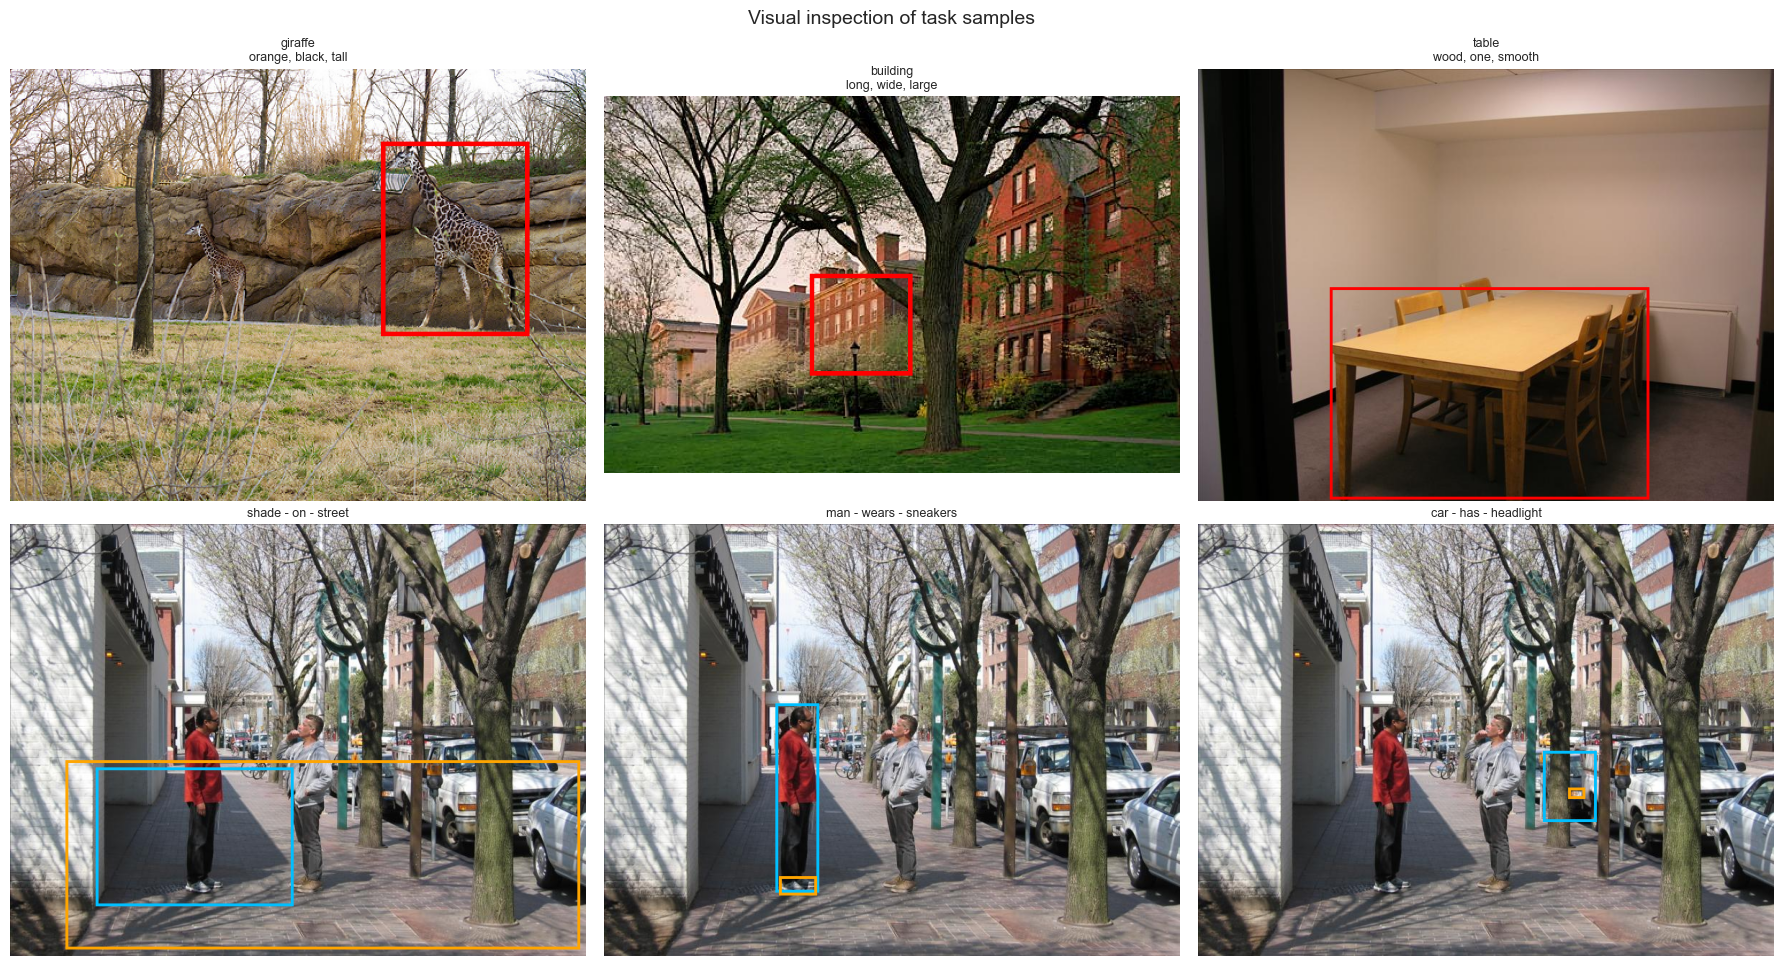

In [5]:
def plot_task1_sample(sample, ax):
    image = load_image(sample['image_id'])
    if image is None:
        ax.axis('off')
        ax.set_title(f"Missing image {sample['image_id']}")
        return

    canvas = image.copy()
    draw = ImageDraw.Draw(canvas)
    x, y, w, h = [int(v) for v in sample['bbox']]
    draw.rectangle([x, y, x + w, y + h], outline='red', width=4)

    label = sample.get('object_name', str(sample['object_label']))
    attributes = sample.get('attribute_names', [])
    subtitle = ', '.join(attributes[:3]) if attributes else ''

    ax.imshow(canvas)
    ax.set_title(f'{label}\n{subtitle}' if subtitle else label, fontsize=9)
    ax.axis('off')


def plot_task2_sample(sample, ax):
    image = load_image(sample['image_id'])
    if image is None:
        ax.axis('off')
        ax.set_title(f"Missing image {sample['image_id']}")
        return

    canvas = image.copy()
    draw = ImageDraw.Draw(canvas)
    sx, sy, sw, sh = [int(v) for v in sample['subject_bbox']]
    ox, oy, ow, oh = [int(v) for v in sample['object_bbox']]
    draw.rectangle([sx, sy, sx + sw, sy + sh], outline='deepskyblue', width=4)
    draw.rectangle([ox, oy, ox + ow, oy + oh], outline='orange', width=4)

    subject_name = sample.get('subject_name', 'subject')
    object_name = sample.get('object_name', 'object')
    relation_name = sample.get('relation_name', 'relation')

    ax.imshow(canvas)
    ax.set_title(f'{subject_name} - {relation_name} - {object_name}', fontsize=9)
    ax.axis('off')


existing_image_ids = {
    int(path.stem)
    for path in (RAW_DIR / 'images').glob('*.jpg')
    if path.stem.isdigit()
}

available_task1 = task1_train[task1_train['image_id'].isin(existing_image_ids)]
available_task2 = task2_train[task2_train['image_id'].isin(existing_image_ids)]

if available_task1.empty:
    available_task1 = task1_train
if available_task2.empty:
    available_task2 = task2_train


task1_examples = available_task1.sort_values(['attribute_count', 'bbox_area'], ascending=[False, False]).head(3)
task2_examples = available_task2.head(3)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes_list = list(axes.flat)

for index, (_, sample) in enumerate(task1_examples.iterrows()):
    plot_task1_sample(sample, axes_list[index])
for index in range(len(task1_examples), 3):
    axes_list[index].axis('off')

for index, (_, sample) in enumerate(task2_examples.iterrows(), start=3):
    plot_task2_sample(sample, axes_list[index])
for index in range(3 + len(task2_examples), 6):
    axes_list[index].axis('off')

fig.suptitle('Visual inspection of task samples', fontsize=14)
plt.tight_layout()
plt.show()